# A small OTLiNGAM tutorial

This notebook generates a linear non-Gaussian system, learns a causal order, and compares the true and estimated weighted adjacency matrices. OTLiNGAM uses one-dimensional Wasserstein distance to measure how far standardized residuals are from a standard Gaussian.

The method is described in [Contrast-Free ICA and Causal Inference via Wasserstein Distances to the Gaussian](https://arxiv.org/abs/2607.12832).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from otlingam import GreedyOTLiNGAM

## Generate a non-Gaussian SEM

Rows are children and columns are parents. The data follow `X = (I - B)^{-T} e` in row-observation form.

In [2]:
# Fix the seed so the generated system and fitted result are reproducible.
rng = np.random.default_rng(42)
n_samples = 5_000

# Each nonzero entry is the effect of a parent column on a child row.
adjacency = np.array(
    [
        [0.0, 0.0, 0.0, 0.0, 0.0],
        [0.8, 0.0, 0.0, 0.0, 0.0],
        [0.0, -0.7, 0.0, 0.0, 0.0],
        [0.5, 0.0, 0.9, 0.0, 0.0],
        [0.0, -0.6, 0.0, 0.7, 0.0],
    ]
)

# Uniform structural noise supplies the non-Gaussianity used for identification.
noise = rng.uniform(-1.0, 1.0, size=(n_samples, adjacency.shape[0]))
X = noise @ np.linalg.inv(np.eye(adjacency.shape[0]) - adjacency).T
X.shape

(5000, 5)

## Learn the order

The greedy estimator is a good starting point when the number of variables is not tiny. It repeatedly chooses the variable whose standardized residual is most non-Gaussian.

In [3]:
# Fit the scalable greedy estimator and inspect its primary diagnostics.
model = GreedyOTLiNGAM().fit(X)
print("Estimated order:", model.causal_order_)
print("Score:", model.score_)

Estimated order: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Score: 0.22742898531602093


## Use OTLiNGAM in a scikit-learn pipeline

OTLiNGAM estimators follow the scikit-learn estimator protocol, so they can be cloned, configured with `get_params` and `set_params`, and placed after preprocessing steps. The fitted estimator exposes `causal_order_`, `adjacency_matrix_`, `score_`, and, when enabled, `intercept_`.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# StandardScaler centers the data, so the causal step need not fit an intercept.
pipeline = Pipeline(
    [
        ("scale", StandardScaler()),
        ("causal", GreedyOTLiNGAM(fit_intercept=False)),
    ]
)
pipeline.fit(X)
fitted = pipeline.named_steps["causal"]
print("Pipeline order:", fitted.causal_order_)

# Rows are children and columns are parents, matching the convention above.
edges = np.argwhere(np.abs(fitted.adjacency_matrix_) > 1e-8)
for child, parent in edges:
    weight = fitted.adjacency_matrix_[child, parent]
    print(f"{parent} -> {child}: {weight:.3f}")

Pipeline order: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
0 -> 1: 0.625
1 -> 2: -0.680
0 -> 3: 0.339
2 -> 3: 0.816
1 -> 4: -0.426
3 -> 4: 0.581


## Compare the fitted graph with the truth

The shared color scale makes missing, extra, and incorrectly weighted edges directly comparable. Rows represent children and columns represent parents in both panels.

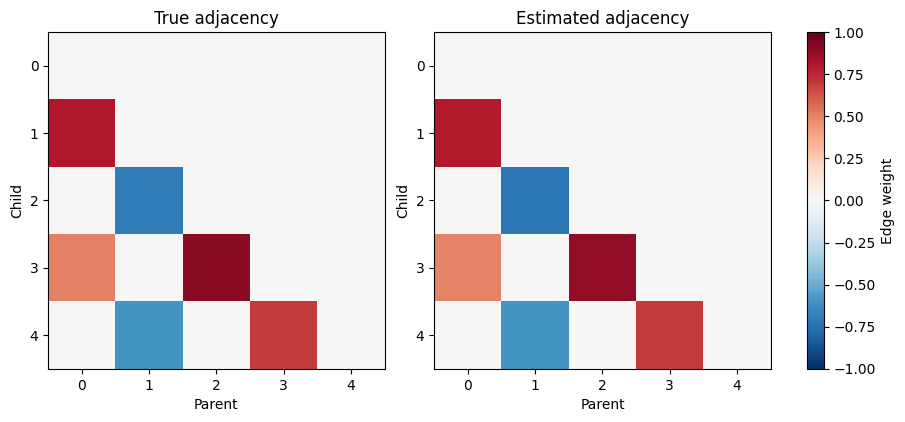

In [5]:
# Plot both matrices with identical limits so colors encode the same weights.
fig, axes = plt.subplots(1, 2, figsize=(9, 4), layout="constrained")
for ax, matrix, title in zip(
    axes,
    (adjacency, model.adjacency_matrix_),
    ("True adjacency", "Estimated adjacency"),
    strict=True,
): 
    image = ax.imshow(matrix, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xlabel("Parent")
    ax.set_ylabel("Child")
fig.colorbar(image, ax=axes, label="Edge weight")
plt.show()

## Choosing another estimator

`ExhaustiveOTLiNGAM` searches all subset states and is useful for small systems. Its exponential cost makes `GreedyOTLiNGAM` the practical default as the dimension grows. `OTICALiNGAM` provides an ICA-LiNGAM route with OTICA source estimation.